# NLP with Disaster Tweets

## 1. Project Introduction

### Problem Statement

Social media platforms such as Twitter provide a large amount of real-time information during emergencies and natural disasters. However, not every tweet containing disaster-related words necessarily refers to an actual disaster.

The objective of this project is to build a Natural Language Processing (NLP) classification model that can distinguish between tweets that describe real disasters and tweets that do not.

### Objective

The main objectives of this project are to:

- Explore and understand the disaster tweet dataset.
- Perform exploratory data analysis to identify patterns and characteristics of the data.
- Clean and preprocess the textual data.
- Convert text into numerical features using TF-IDF.
- Train and compare multiple machine learning classification models.
- Evaluate the performance of the trained models.
- Select the best-performing model.
- Generate predictions for the unseen test dataset.
- Create a submission file for the Kaggle competition.

### Dataset

The dataset is provided as part of the Kaggle competition **NLP with Disaster Tweets**.

It contains tweets along with additional information such as keywords and locations. The training dataset contains the target variable indicating whether a tweet is related to a real disaster.

### Dataset Features

| Feature | Description |
|---|---|
| `id` | Unique identifier for each tweet |
| `keyword` | Disaster-related keyword extracted from the tweet |
| `location` | Location associated with the tweet |
| `text` | The actual tweet text |
| `target` | Target variable: `1` for a real disaster and `0` otherwise |

### Machine Learning Approach

The project follows a traditional NLP classification pipeline:

**Raw Text → Text Cleaning → TF-IDF Feature Extraction → Model Training → Model Evaluation → Prediction**

The following machine learning algorithms will be compared:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine

### Expected Outcome

The final outcome of this project is a machine learning model capable of classifying disaster-related tweets and generating predictions for the Kaggle test dataset.

## 2. Import Libraries

The libraries required for data manipulation, visualization, text preprocessing, feature extraction, machine learning, and model evaluation are imported in this section.

In [1]:
# ==========================================
# Data Manipulation
# ==========================================

import numpy as np
import pandas as pd

In [2]:
# ==========================================
# Data Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ==========================================
# Text Preprocessing
# ==========================================

import re
import string

In [4]:
# ==========================================
# Data Splitting and Feature Extraction
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
# ==========================================
# Machine Learning Models
# ==========================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [6]:
# ==========================================
# Model Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [7]:
# ==========================================
# Warning Management
# ==========================================

import warnings

warnings.filterwarnings("ignore")

### Library Overview

| Library / Module | Purpose |
|---|---|
| NumPy | Numerical operations and array handling |
| Pandas | Data loading, manipulation, and analysis |
| Matplotlib | Data visualization |
| Seaborn | Statistical data visualization |
| `re` | Regular expressions for text cleaning |
| `string` | Handling and removing punctuation |
| `train_test_split` | Splitting the dataset into training and validation sets |
| `TfidfVectorizer` | Converting text into numerical TF-IDF features |
| `MultinomialNB` | Naive Bayes classification |
| `LogisticRegression` | Logistic Regression classification |
| `LinearSVC` | Linear Support Vector Machine classification |
| `sklearn.metrics` | Model performance evaluation |
| `warnings` | Suppressing unnecessary warning messages |

## 3. Load Dataset

The dataset provided for the competition consists of a training dataset and a testing dataset.

The training dataset contains the tweet text along with the target variable, while the testing dataset contains tweets for which predictions need to be generated.

In this section, both datasets are loaded and their structure is examined before beginning the exploratory data analysis.

In [8]:
# ==========================================
# Load the Datasets
# ==========================================

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [9]:
# ==========================================
# Display the First Five Rows
# ==========================================

print("Training Dataset")
display(train_df.head())

print("\nTesting Dataset")
display(test_df.head())

Training Dataset


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1



Testing Dataset


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [10]:
# ==========================================
# Dataset Dimensions
# ==========================================

print(f"Training Dataset Shape: {train_df.shape}")
print(f"Testing Dataset Shape : {test_df.shape}")

Training Dataset Shape: (7613, 5)
Testing Dataset Shape : (3263, 4)


In [11]:
# ==========================================
# Column Names
# ==========================================

print("Training Dataset Columns:")
print(train_df.columns.tolist())

print("\nTesting Dataset Columns:")
print(test_df.columns.tolist())

Training Dataset Columns:
['id', 'keyword', 'location', 'text', 'target']

Testing Dataset Columns:
['id', 'keyword', 'location', 'text']


In [12]:
# ==========================================
# Dataset Information
# ==========================================

print("Training Dataset Information")
train_df.info()

print("\n" + "=" * 60 + "\n")

print("Testing Dataset Information")
test_df.info()

Training Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


Testing Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        3263 non-null   int64
 1   keyword   3237 non-null   str  
 2   location  2158 non-null   str  
 3   text      3263 non-null   str  
dtypes: int64(1), str(3)
memory usage: 102.1 KB


In [13]:
# ==========================================
# Missing Values
# ==========================================

print("Missing Values in Training Dataset")
display(train_df.isnull().sum())

print("\nMissing Values in Testing Dataset")
display(test_df.isnull().sum())

Missing Values in Training Dataset


id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


Missing Values in Testing Dataset


id             0
keyword       26
location    1105
text           0
dtype: int64

In [14]:
# ==========================================
# Statistical Summary
# ==========================================

train_df.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


### Initial Dataset Observations

From the initial inspection:

- The training dataset contains the `target` variable required for supervised learning.
- The testing dataset does not contain the `target` variable.
- The `text` column contains the primary information that will be used for NLP classification.
- The `keyword` and `location` columns contain missing values.
- The `id` column uniquely identifies each tweet and will be retained for the final submission.
- Further analysis of the data will be performed during Exploratory Data Analysis.

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and important characteristics of the dataset before building the machine learning models.

In this section, we will examine the target variable, missing values, tweet lengths, and frequently occurring keywords to identify patterns that may be useful for classification.

### 4.1 Dataset Overview

In [15]:
# ==========================================
# Dataset Overview
# ==========================================

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)

print("\nTraining Dataset:")
display(train_df.head())

print("\nTraining Dataset Sample:")
display(train_df.sample(5, random_state=42))

Training Dataset Shape: (7613, 5)
Testing Dataset Shape : (3263, 4)

Training Dataset:


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1



Training Dataset Sample:


,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


### 4.2 Target Variable Distribution

The `target` column is the variable that we want the machine learning model to predict.

- `0` represents a tweet that is not related to a real disaster.
- `1` represents a tweet that is related to a real disaster.

Examining the distribution of these classes helps determine whether the dataset is balanced or suffers from class imbalance.

In [16]:
# ==========================================
# Target Class Distribution
# ==========================================

target_counts = train_df["target"].value_counts()

print("Target Value Counts:")
display(target_counts)

Target Value Counts:


target
0    4342
1    3271
Name: count, dtype: int64

In [17]:
# ==========================================
# Target Class Percentages
# ==========================================

target_percentages = train_df["target"].value_counts(normalize=True) * 100

print("Target Class Distribution (%):")
display(target_percentages.round(2))

Target Class Distribution (%):


target
0    57.03
1    42.97
Name: proportion, dtype: float64

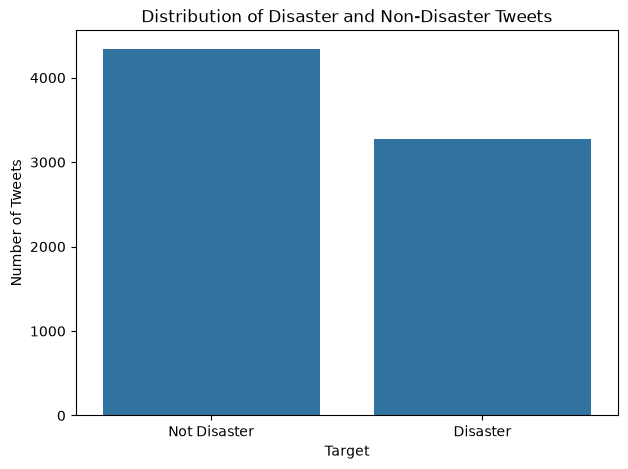

In [18]:
# ==========================================
# Visualize Target Distribution
# ==========================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_df,
    x="target"
)

plt.title("Distribution of Disaster and Non-Disaster Tweets")
plt.xlabel("Target")
plt.ylabel("Number of Tweets")
plt.xticks(
    [0, 1],
    ["Not Disaster", "Disaster"]
)

plt.show()

The target distribution provides an initial understanding of the two classes. The classes are reasonably balanced, meaning that a severe class imbalance is not expected to be a major issue during model training.

### 4.3 Missing Values

Missing values are common in real-world datasets and can affect subsequent analysis and model performance.

The `keyword` and `location` columns contain missing values, while the `text` and `target` columns are complete. The missing values will be considered during preprocessing and feature engineering.

In [19]:
# ==========================================
# Missing Value Summary
# ==========================================

missing_values = train_df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(train_df) * 100).round(2)
})

display(missing_summary)

,Missing Values,Percentage
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


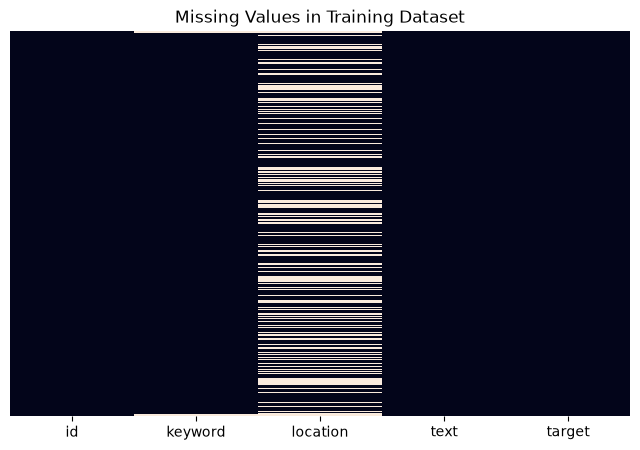

In [20]:
# ==========================================
# Missing Values Heatmap
# ==========================================

plt.figure(figsize=(8, 5))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Training Dataset")

plt.show()

### 4.4 Tweet Length Analysis

Tweet length can provide useful information about the characteristics of the dataset.

A new temporary feature, `tweet_length`, is created by calculating the number of characters in each tweet. This feature is used only for exploratory analysis and is not directly used for model training.

In [21]:
# ==========================================
# Calculate Tweet Length
# ==========================================

train_df["tweet_length"] = train_df["text"].str.len()

display(
    train_df[["text", "tweet_length"]].head()
)

,text,tweet_length
0,Our Deeds are the Reason of this #earthquake M...,69
1,Forest fire near La Ronge Sask. Canada,38
2,All residents asked to 'shelter in place' are ...,133
3,"13,000 people receive #wildfires evacuation or...",65
4,Just got sent this photo from Ruby #Alaska as ...,88


In [22]:
# ==========================================
# Tweet Length Statistics
# ==========================================

train_df["tweet_length"].describe()

count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: tweet_length, dtype: float64

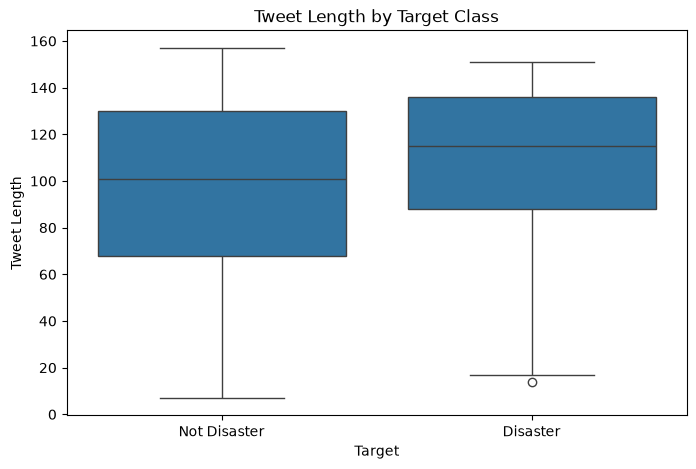

In [23]:
# ==========================================
# Tweet Length by Target Class
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train_df,
    x="target",
    y="tweet_length"
)

plt.title("Tweet Length by Target Class")
plt.xlabel("Target")
plt.ylabel("Tweet Length")

plt.xticks(
    [0, 1],
    ["Not Disaster", "Disaster"]
)

plt.show()

### 4.5 Keyword Analysis

The `keyword` column contains disaster-related keywords extracted from the tweets.

Analyzing the frequency of these keywords can help identify which disaster-related terms occur most frequently in the dataset.

In [24]:
# ==========================================
# Most Frequent Keywords
# ==========================================

keyword_counts = (
    train_df["keyword"]
    .dropna()
    .value_counts()
    .head(15)
)

display(keyword_counts)

keyword
fatalities     45
armageddon     42
deluge         42
body%20bags    41
damage         41
harm           41
sinking        41
collided       40
evacuate       40
fear           40
outbreak       40
siren          40
twister        40
windstorm      40
collision      39
Name: count, dtype: int64

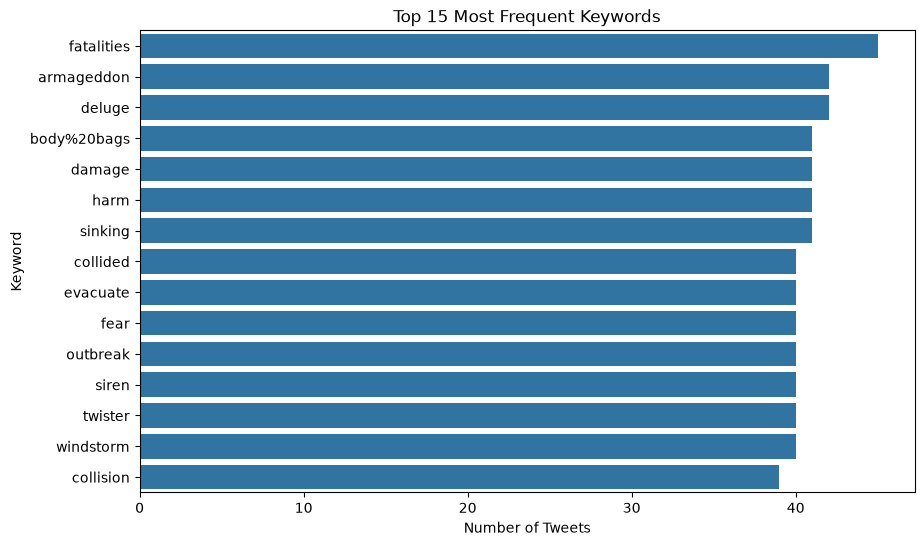

In [25]:
# ==========================================
# Visualize Most Frequent Keywords
# ==========================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=keyword_counts.values,
    y=keyword_counts.index
)

plt.title("Top 15 Most Frequent Keywords")
plt.xlabel("Number of Tweets")
plt.ylabel("Keyword")

plt.show()

### 4.6 Sample Tweets

Examining individual examples provides a better understanding of how disaster and non-disaster tweets differ in their language and context.

In [26]:
# ==========================================
# Sample Disaster Tweets
# ==========================================

print("Sample Disaster Tweets:\n")

display(
    train_df.loc[
        train_df["target"] == 1,
        ["text", "keyword", "location"]
    ].sample(5, random_state=42)
)

Sample Disaster Tweets:



,text,keyword,location
4008,Nearly 50 thousand people affected by floods i...,floods,North America
325,Vladimir Putin Issues Major Warning But Is It ...,armageddon,"Florida, USA"
1215,@DoctorFluxx @StefanEJones @spinnellii @themer...,buildings%20burning,somewhere over a rainbow
494,Telnet attacked from 124.13.172.40 (STREAMYX-H...,attacked,NaN
2961,LONDON IS DROWNING AND IIII LIVE BY THE RIVEEE...,drowning,Numa casa de old yellow bricks


In [27]:
# ==========================================
# Sample Non-Disaster Tweets
# ==========================================

print("Sample Non-Disaster Tweets:\n")

display(
    train_df.loc[
        train_df["target"] == 0,
        ["text", "keyword", "location"]
    ].sample(5, random_state=42)
)

Sample Non-Disaster Tweets:



,text,keyword,location
3697,Everyday is a near death fatality for me on th...,fatality,NaN
4180,#Lifestyle Û÷It makes me sickÛª: Baby clothe...,hazard,Australia
4634,@Lenn_Len Probably. We are inundated with them...,inundated,"England & Wales Border, UK"
6135,A demoness with the voice of an angel. Like a ...,siren,"Tampa, FL"
4568,Next Man Up---AH SCREW THIS! I'm so tired of i...,injuries,Scottsdale. AZ


### EDA Summary

The exploratory analysis provides several useful observations:

- The target variable contains two classes: disaster and non-disaster tweets.
- The class distribution is reasonably balanced.
- Missing values are present primarily in the `keyword` and `location` columns.
- Tweet lengths vary considerably across the dataset.
- The distribution of tweet lengths can differ between disaster and non-disaster tweets.
- Several disaster-related keywords occur frequently throughout the dataset.
- Examining actual tweets shows that contextual meaning is important, making text preprocessing and feature extraction essential for the classification task.

The next step is to clean the raw tweet text and prepare it for machine learning.

## 5. Data Cleaning and Preprocessing

Raw tweets contain several elements that may introduce noise into the classification process, such as URLs, user mentions, punctuation, numbers, and inconsistent capitalization.

Text preprocessing is performed to standardize the tweets and retain the information that is most useful for classification.

The preprocessing steps used in this project are:

1. Convert text to lowercase.
2. Remove URLs.
3. Remove user mentions.
4. Remove the hashtag symbol while preserving the hashtag word.
5. Remove numbers.
6. Remove punctuation.
7. Remove extra whitespace.

The cleaned text will later be converted into numerical features using TF-IDF.

### 5.1 Text Cleaning Function

A custom text-cleaning function is created using Python's `re` module for regular expressions and the `string` module for punctuation handling.

The function takes a raw tweet as input and returns a standardized version of the tweet.

In [28]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):
    """
    Clean a tweet by removing unnecessary textual elements.

    Parameters
    ----------
    text : str
        Raw tweet text.

    Returns
    -------
    str
        Cleaned tweet text.
    """

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove user mentions
    text = re.sub(r"@\w+", "", text)

    # Remove the hashtag symbol while keeping the word
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

### 5.2 Apply Text Cleaning

The cleaning function is applied to the `text` column of both the training and testing datasets.

The original `text` column is retained so that the effect of preprocessing can be compared with the original tweets.

In [29]:
# ==========================================
# Create Cleaned Text Columns
# ==========================================

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

### 5.3 Original vs Cleaned Tweets

A comparison of the original and cleaned tweets helps verify whether the preprocessing function is working as intended.

In [30]:
# ==========================================
# Compare Original and Cleaned Tweets
# ==========================================

text_comparison = train_df[
    ["text", "clean_text"]
].head(10)

display(text_comparison)

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed in both...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,im on top of the hill and i can see a fire in ...
8,There's an emergency evacuation happening now ...,theres an emergency evacuation happening now i...
9,I'm afraid that the tornado is coming to our a...,im afraid that the tornado is coming to our area


### 5.4 Check the Cleaned Data

After preprocessing, the cleaned text is checked for missing values and empty strings.

This ensures that the feature extraction stage receives valid textual input.

In [31]:
# ==========================================
# Check Missing Values
# ==========================================

print("Missing values in cleaned training text:",
      train_df["clean_text"].isnull().sum())

print("Missing values in cleaned testing text:",
      test_df["clean_text"].isnull().sum())

Missing values in cleaned training text: 0
Missing values in cleaned testing text: 0


In [32]:
# ==========================================
# Check Empty Strings
# ==========================================

print("Empty cleaned training tweets:",
      (train_df["clean_text"] == "").sum())

print("Empty cleaned testing tweets:",
      (test_df["clean_text"] == "").sum())

Empty cleaned training tweets: 0
Empty cleaned testing tweets: 0


In [33]:
# ==========================================
# Length of Cleaned Tweets
# ==========================================

clean_text_lengths = train_df["clean_text"].str.len()

clean_text_lengths.describe()

count    7613.000000
mean       77.393406
std        31.082596
min         3.000000
25%        54.000000
50%        78.000000
75%       103.000000
max       145.000000
Name: clean_text, dtype: float64

### Preprocessing Summary

The text data has now been standardized by:

- Converting all text to lowercase.
- Removing URLs.
- Removing user mentions.
- Removing the `#` symbol while preserving hashtag words.
- Removing numbers.
- Removing punctuation.
- Removing unnecessary whitespace.

The resulting `clean_text` column contains the text that will be used for feature extraction.

The next step is to convert this textual information into numerical features that can be processed by machine learning algorithms.

## 6. Feature Engineering

Machine learning algorithms cannot directly process raw textual data. Therefore, the cleaned tweets must be transformed into numerical features.

In this project, **TF-IDF (Term Frequency–Inverse Document Frequency)** is used to represent the importance of words in the tweets.

The vectorizer will use:

- **Unigrams**: Individual words such as `fire`, `earthquake`, and `disaster`.
- **Bigrams**: Pairs of consecutive words such as `forest fire` and `natural disaster`.
- **English stop-word removal** to reduce the influence of very common words.
- A maximum vocabulary size of **10,000 features** to control dimensionality.

The resulting sparse feature matrix will be used as input for the machine learning models.

### 6.1 Prepare Features and Target

The cleaned tweet text is used as the primary input feature, while the `target` column is used as the classification target.

The test dataset does not contain the target variable because it is the unseen data for which predictions will eventually be generated.

In [34]:
# ==========================================
# Define Features and Target
# ==========================================

X = train_df["clean_text"]
y = train_df["target"]

X_test = test_df["clean_text"]

print("Feature samples:")
display(X.head())

print("\nTarget samples:")
display(y.head())

Feature samples:


0    our deeds are the reason of this earthquake ma...
1                forest fire near la ronge sask canada
2    all residents asked to shelter in place are be...
3    people receive wildfires evacuation orders in ...
4    just got sent this photo from ruby alaska as s...
Name: clean_text, dtype: str


Target samples:


0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

### 6.2 Train-Validation Split

The labeled training data is divided into training and validation sets.

The training set is used to train the machine learning models, while the validation set is used to evaluate their performance on previously unseen data.

A validation size of **20%** is used, and `stratify=y` ensures that both sets maintain approximately the same proportion of disaster and non-disaster tweets.

In [35]:
# ==========================================
# Train-Validation Split
# ==========================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_valid))

Training samples  : 6090
Validation samples: 1523


### 6.3 TF-IDF Vectorization

TF-IDF measures how important a word is within a particular document relative to the entire collection of documents.

It consists of two main concepts:

- **Term Frequency (TF):** Measures how frequently a term occurs in a document.
- **Inverse Document Frequency (IDF):** Reduces the importance of terms that occur across many documents.

The combination produces a numerical representation in which informative words receive greater weight.

The vectorizer is fitted only on the training data to prevent information from the validation or test sets from influencing the feature vocabulary.

In [36]:
# ==========================================
# Initialize TF-IDF Vectorizer
# ==========================================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

In [37]:
# ==========================================
# Fit and Transform Training Data
# ==========================================

X_train_tfidf = tfidf.fit_transform(X_train)

print("Training TF-IDF Matrix Shape:",
      X_train_tfidf.shape)

Training TF-IDF Matrix Shape: (6090, 10000)


In [38]:
# ==========================================
# Transform Validation and Test Data
# ==========================================

X_valid_tfidf = tfidf.transform(X_valid)

X_test_tfidf = tfidf.transform(X_test)

print("Validation TF-IDF Matrix Shape:",
      X_valid_tfidf.shape)

print("Test TF-IDF Matrix Shape:",
      X_test_tfidf.shape)

Validation TF-IDF Matrix Shape: (1523, 10000)
Test TF-IDF Matrix Shape: (3263, 10000)


### 6.4 Inspect the TF-IDF Vocabulary

The vectorizer creates a vocabulary containing the terms identified from the training data.

Inspecting a sample of the vocabulary helps verify that the text has been successfully converted into meaningful features.

In [39]:
# ==========================================
# Inspect Vocabulary
# ==========================================

feature_names = tfidf.get_feature_names_out()

print("Number of extracted features:",
      len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of extracted features: 10000

First 30 features:
['aa batteries' 'aaaaaaallll' 'aaaaaaallll ûªm' 'aaaaaand'
 'aaaaaand theres' 'aaarrrgghhh' 'aal' 'aampb' 'aampb pipeliners' 'aampw'
 'aampw pmclose' 'aan' 'aan den' 'aannnnd' 'aannnnd reddit' 'aba'
 'aba woman' 'abandon' 'abandoned' 'abandoned aircraft' 'abbott'
 'abbswinston' 'abbswinston zionist' 'abc' 'abc news' 'abia' 'ability'
 'ablaze' 'ablaze california' 'able']


In [40]:
# ==========================================
# Inspect TF-IDF Values
# ==========================================

tfidf_sample = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=feature_names
)

display(tfidf_sample.iloc[:, :15])

,aa batteries,aaaaaaallll,aaaaaaallll ûªm,aaaaaand,aaaaaand theres,aaarrrgghhh,aal,aampb,aampb pipeliners,aampw,aampw pmclose,aan,aan den,aannnnd,aannnnd reddit
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Feature Engineering Summary

The cleaned tweet text has now been transformed into numerical TF-IDF feature matrices.

The resulting datasets are:

- `X_train_tfidf` — TF-IDF features for model training.
- `X_valid_tfidf` — TF-IDF features for validation.
- `X_test_tfidf` — TF-IDF features for final predictions.

The use of unigrams and bigrams allows the models to capture both individual words and short phrases that may provide useful contextual information.

These numerical features are now ready to be used for machine learning model training.

## 7. Model Building

The TF-IDF feature matrices generated in the previous section are now used to train supervised machine learning classification models.

Three traditional machine learning algorithms are evaluated:

1. **Multinomial Naive Bayes** — a probabilistic classifier commonly used for text classification.
2. **Logistic Regression** — a linear classification algorithm that estimates the probability of class membership.
3. **Linear Support Vector Machine (Linear SVC)** — a linear classifier that is particularly effective for high-dimensional and sparse text data.

All three models are trained using the same training data and evaluated on the same validation set to ensure a fair comparison.

### 7.1 Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem.

It is particularly suitable for Natural Language Processing because it can work effectively with high-dimensional representations such as TF-IDF.

The model assumes conditional independence between features given the class.

In [41]:
# ==========================================
# Multinomial Naive Bayes
# ==========================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_valid_tfidf
)

nb_accuracy = accuracy_score(
    y_valid,
    nb_predictions
)

print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy:.4f}")

Multinomial Naive Bayes Accuracy: 0.8076


### 7.2 Logistic Regression

Logistic Regression is a supervised learning algorithm commonly used for binary classification.

It estimates the probability of an observation belonging to a particular class and uses a decision boundary to classify the observation.

Logistic Regression is effective for text classification when combined with TF-IDF features.

In [42]:
# ==========================================
# Logistic Regression
# ==========================================

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_predictions = lr_model.predict(
    X_valid_tfidf
)

lr_accuracy = accuracy_score(
    y_valid,
    lr_predictions
)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.8194


### 7.3 Linear Support Vector Machine

Linear Support Vector Machine (Linear SVC) is a supervised classification algorithm that attempts to find an optimal decision boundary between different classes.

It is particularly effective for text classification because text data represented using TF-IDF generally contains a large number of sparse features.

The Linear SVC model will also be considered as a candidate for the final model based on its validation performance.

In [43]:
# ==========================================
# Linear Support Vector Machine
# ==========================================

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(
    X_valid_tfidf
)

svm_accuracy = accuracy_score(
    y_valid,
    svm_predictions
)

print(f"Linear SVM Accuracy: {svm_accuracy:.4f}")

Linear SVM Accuracy: 0.7971


### 7.4 Model Comparison

The validation accuracy of the three models is compared to identify the best-performing classifier.

Accuracy is calculated as the proportion of correctly classified tweets out of the total number of tweets in the validation set.

In [44]:
# ==========================================
# Model Accuracy Comparison
# ==========================================

model_results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Validation Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ]
})

model_results = model_results.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)

display(model_results)

,Model,Validation Accuracy
0,Logistic Regression,0.819435
1,Multinomial Naive Bayes,0.807617
2,Linear SVM,0.797111


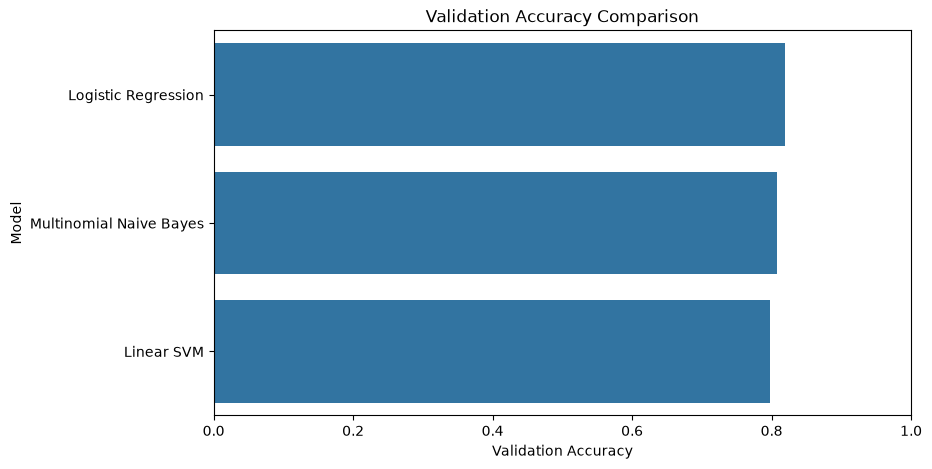

In [45]:
# ==========================================
# Visualize Model Performance
# ==========================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_results,
    x="Validation Accuracy",
    y="Model"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Validation Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()

### 7.5 Select the Best Model

The model with the highest validation accuracy is selected as the best-performing model among the three candidates.

Its predictions will be examined further using additional evaluation metrics and a confusion matrix in the next section.

In [46]:
# ==========================================
# Identify Best Model
# ==========================================

best_model_name = model_results.iloc[0]["Model"]
best_accuracy = model_results.iloc[0]["Validation Accuracy"]

print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {best_accuracy:.4f}")

Best Model: Logistic Regression
Validation Accuracy: 0.8194


## 8. Model Evaluation

After comparing the three machine learning models, the best-performing model is evaluated in greater detail.

Model evaluation helps determine not only how many predictions are correct, but also how well the model identifies each class.

The following evaluation metrics are considered:

- **Accuracy:** Proportion of correctly classified observations.
- **Precision:** Proportion of predicted positive observations that are actually positive.
- **Recall:** Proportion of actual positive observations that are correctly identified.
- **F1-score:** Harmonic mean of precision and recall.

A classification report and confusion matrix are also used to examine the model's performance in greater detail.

### 8.1 Predictions of the Best Model

The predictions generated by the best-performing model in the previous section are used for detailed evaluation.

Since the current model comparison is based on validation data, the following evaluation is performed on the same validation set.

In [47]:
# ==========================================
# Select Best Model Predictions
# ==========================================

if best_model_name == "Multinomial Naive Bayes":
    best_predictions = nb_predictions

elif best_model_name == "Logistic Regression":
    best_predictions = lr_predictions

else:
    best_predictions = svm_predictions

print("Selected Model:", best_model_name)

Selected Model: Logistic Regression


### 8.2 Accuracy

Accuracy measures the proportion of predictions that the model classified correctly out of all validation observations.

Although accuracy provides a useful overall measure, it should be considered alongside precision, recall, and F1-score.

In [48]:
# ==========================================
# Calculate Accuracy
# ==========================================

final_validation_accuracy = accuracy_score(
    y_valid,
    best_predictions
)

print(
    f"Validation Accuracy: "
    f"{final_validation_accuracy:.4f}"
)

Validation Accuracy: 0.8194


### 8.3 Classification Report

The classification report provides precision, recall, and F1-score for each target class.

These metrics provide a more detailed view of the model's ability to distinguish between disaster and non-disaster tweets.

In [49]:
# ==========================================
# Classification Report
# ==========================================

print(
    classification_report(
        y_valid,
        best_predictions,
        target_names=[
            "Not Disaster",
            "Disaster"
        ]
    )
)

              precision    recall  f1-score   support

Not Disaster       0.80      0.91      0.85       869
    Disaster       0.85      0.70      0.77       654

    accuracy                           0.82      1523
   macro avg       0.83      0.80      0.81      1523
weighted avg       0.82      0.82      0.82      1523



### 8.4 Confusion Matrix

A confusion matrix summarizes the model's predictions by comparing the actual classes with the predicted classes.

It contains four types of outcomes:

- **True Negative (TN):** Non-disaster tweet correctly classified as non-disaster.
- **False Positive (FP):** Non-disaster tweet incorrectly classified as a disaster.
- **False Negative (FN):** Disaster tweet incorrectly classified as non-disaster.
- **True Positive (TP):** Disaster tweet correctly classified as a disaster.

The confusion matrix helps identify the types of classification errors made by the model.

In [50]:
# ==========================================
# Calculate Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_valid,
    best_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[789  80]
 [195 459]]


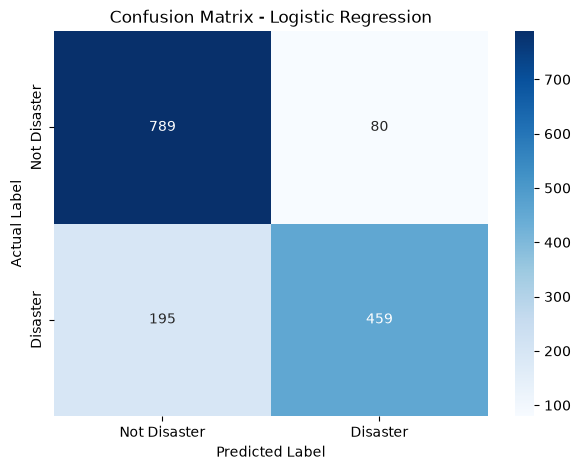

In [51]:
# ==========================================
# Visualize Confusion Matrix
# ==========================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Disaster",
        "Disaster"
    ],
    yticklabels=[
        "Not Disaster",
        "Disaster"
    ]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### 8.5 Evaluation Summary

The selected model is evaluated using multiple performance metrics rather than relying solely on accuracy.

The confusion matrix provides additional insight into the model's classification errors, while precision, recall, and F1-score provide class-specific performance information.

Based on the validation results, the selected model provides a strong baseline for classifying disaster-related tweets.

The model will now be retrained using the complete labeled training dataset before generating predictions for the Kaggle test dataset.

## 9. Final Model and Predictions

After evaluating the candidate models on the validation dataset, the best-performing model is selected for the final prediction stage.

Instead of training the final model only on the training portion used during validation, the selected model is now trained using the complete labeled training dataset.

The TF-IDF vectorizer is also fitted on the complete training text before transforming the test dataset.

The final model is then used to predict the target class of each tweet in the test dataset, and the predictions are saved in the format required for the Kaggle competition.

### 9.1 Prepare the Complete Training Data

The validation split was used only for model comparison and evaluation.

For the final model, the complete labeled training dataset is used so that the selected algorithm can learn from all available training examples.

In [52]:
# ==========================================
# Prepare Complete Training Data
# ==========================================

X_full = train_df["clean_text"]
y_full = train_df["target"]

X_test_final = test_df["clean_text"]

print("Full Training Samples:", len(X_full))
print("Test Samples:", len(X_test_final))

Full Training Samples: 7613
Test Samples: 3263


### 9.2 Fit the Final TF-IDF Vectorizer

The TF-IDF vectorizer is fitted again using the complete training dataset.

This allows the final feature representation to be constructed using all available labeled training tweets.

The test dataset is only transformed using the fitted vectorizer and does not influence the vocabulary or IDF calculations.

In [53]:
# ==========================================
# Final TF-IDF Vectorization
# ==========================================

final_tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_full_tfidf = final_tfidf.fit_transform(X_full)

X_test_final_tfidf = final_tfidf.transform(
    X_test_final
)

print(
    "Full Training TF-IDF Shape:",
    X_full_tfidf.shape
)

print(
    "Test TF-IDF Shape:",
    X_test_final_tfidf.shape
)

Full Training TF-IDF Shape: (7613, 10000)
Test TF-IDF Shape: (3263, 10000)


### 9.3 Train the Final Model

The model identified as the best-performing classifier during validation is now trained on the complete training dataset.

This allows the final model to make use of all available labeled examples before generating predictions for the competition test dataset.

In [54]:
# ==========================================
# Initialize the Final Model
# ==========================================

if best_model_name == "Multinomial Naive Bayes":
    final_model = MultinomialNB()

elif best_model_name == "Logistic Regression":
    final_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

else:
    final_model = LinearSVC(
        random_state=42
    )

# Train using the complete training dataset
final_model.fit(
    X_full_tfidf,
    y_full
)

print(f"Final Model: {best_model_name}")
print("Final model trained successfully.")

Final Model: Logistic Regression
Final model trained successfully.


### 9.4 Generate Test Predictions

The trained final model is used to classify every tweet in the test dataset.

Each prediction is either:

- `0` — Not a real disaster
- `1` — Real disaster

In [55]:
# ==========================================
# Generate Test Predictions
# ==========================================

test_predictions = final_model.predict(
    X_test_final_tfidf
)

print("Predictions generated successfully.")
print("Number of predictions:", len(test_predictions))

Predictions generated successfully.
Number of predictions: 3263


In [56]:
# ==========================================
# Inspect Predictions
# ==========================================

prediction_counts = pd.Series(
    test_predictions
).value_counts()

display(prediction_counts)

0    2151
1    1112
Name: count, dtype: int64

### 9.5 Create Submission DataFrame

The Kaggle competition requires a submission file containing the original tweet `id` and the predicted `target`.

The submission DataFrame is therefore constructed using these two columns.

In [57]:
# ==========================================
# Create Submission DataFrame
# ==========================================

submission = pd.DataFrame({
    "id": test_df["id"],
    "target": test_predictions
})

display(submission.head())

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


In [58]:
# ==========================================
# Check Submission Structure
# ==========================================

print("Submission Shape:", submission.shape)

print("\nSubmission Columns:")
print(submission.columns.tolist())

print("\nMissing Values:")
display(submission.isnull().sum())

Submission Shape: (3263, 2)

Submission Columns:
['id', 'target']

Missing Values:


id        0
target    0
dtype: int64

### 9.6 Save Submission File

The final predictions are saved as `submission.csv`.

This file follows the format required by the Kaggle **NLP with Disaster Tweets** competition and can be uploaded to Kaggle for leaderboard evaluation.

In [60]:
# ==========================================
# Save Submission File
# ==========================================

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


In [61]:
# ==========================================
# Verify Submission File
# ==========================================

import os

print("Files in the current directory:")

for file in os.listdir("."):
    print(file)

Files in the current directory:
NLP-Disaster-Tweets.ipynb
submission.csv


In [62]:
# ==========================================
# Display Final Submission
# ==========================================

display(
    pd.read_csv("submission.csv").head(10)
)

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


### 9.8 Final Submission Information

The final submission file contains:

- `id` — The original identifier of each test tweet.
- `target` — The predicted class generated by the final machine learning model.

The file is now ready to be submitted to Kaggle.

**Kaggle Public Leaderboard Score from the earlier submission: 0.77627**

## 10. Conclusion

This project demonstrated an end-to-end Natural Language Processing workflow for classifying disaster-related tweets.

The project began with exploratory data analysis to understand the dataset, target distribution, missing values, tweet lengths, and frequently occurring keywords.

The raw tweet text was then cleaned through several preprocessing techniques, including:

- Lowercase conversion
- URL removal
- User mention removal
- Hashtag symbol removal
- Number removal
- Punctuation removal
- Whitespace normalization

The cleaned text was converted into numerical features using **TF-IDF Vectorization**, with both unigrams and bigrams considered.

Three machine learning classification algorithms were trained and compared:

- Multinomial Naive Bayes
- Logistic Regression
- Linear Support Vector Machine

The models were evaluated using validation accuracy, precision, recall, F1-score, classification reports, and a confusion matrix. The best-performing model was subsequently trained on the complete labeled training dataset.

Finally, predictions were generated for the unseen test dataset and saved in the required `submission.csv` format.

### Final Kaggle Result

The earlier Kaggle submission achieved a **Public Leaderboard Score of 0.77627**.

### Key Learning Outcomes

Through this project, the following concepts were applied:

- Exploratory Data Analysis
- Text preprocessing
- Regular expressions
- Feature engineering
- TF-IDF
- N-gram feature extraction
- Train-validation splitting
- Supervised machine learning
- Classification
- Model comparison
- Performance evaluation
- Confusion matrix analysis
- Kaggle submission generation

### Final Project Pipeline

**Raw Tweets → EDA → Text Cleaning → Train-Validation Split → TF-IDF → Model Training → Model Comparison → Model Evaluation → Final Model → Test Predictions → Kaggle Submission**

This project provides a foundation for further experimentation with more advanced NLP techniques such as word embeddings, recurrent neural networks, and transformer-based models.